## 1. Imports

In [1]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from flow_tree_utils import compute_extended_explore_traj, compute_explore_traj, generate_traj_from_path, generate_flow_tree_from_trajs

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [2]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

### Load test df

In [3]:
# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
test_df["accuracy"] = test_df["accuracy"].astype(bool)

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)

### Load explore df

In [4]:
# load explore df
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

### Load subject df

In [5]:
subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(explore_df, subject_df, on="Subject")
merged_test_df = pd.merge(test_df, subject_df, on="Subject")

## 3. Set up how to run hypothesis test

1. Compute Flow Trees
2. Compute features on Flow Trees
3. Run appropriate statistical test


In [6]:
from scipy.spatial.distance import pdist
from scipy import stats 


def vector_statistic(x, y, axis):
    mean_x = np.mean(x, axis=axis)
    mean_y = np.mean(y, axis=axis)
        
    # Calculate Euclidean distance
    dist = mean_x - mean_y
    # print(f"Distance between means: {dist}")  # Debug print

    return dist

def run_ttest(group1_reps, group2_reps, statistic=vector_statistic):
    # Perform a t-test on groups
    t_stat, p_value = stats.ttest_ind(group1_reps, group2_reps)
    print(f"Group 1 mean: {np.mean(group1_reps):.2f} (var={np.var(group1_reps):.2f}; n={len(group1_reps)})")
    print(f"Group 2 mean: {np.mean(group2_reps):.2f} (var={np.var(group2_reps):.2f}; n={len(group2_reps)})")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    # mean1, var1, n1 = np.mean(group1_reps), np.var(group1_reps), len(group1_reps)
    # mean2, var2, n2 = np.mean(group2_reps), np.var(group2_reps), len(group2_reps)
    # t = (mean1 - mean2) / np.sqrt((var1/n1 + var2/n2))
    # print("Number samples:", n1, n2)
    # print("T homemade:", t)

    return t_stat, p_value


def run_permutation_test(group1_reps, group2_reps, statistic=vector_statistic):
    res = stats.permutation_test((group1_reps, group2_reps), statistic, vectorized=True,
                       n_resamples=9999,# np.inf,
                       alternative='two-sided')
    print(f"Permutation test result: {res.statistic:.4} (p={res.pvalue:.4})")

    if len(group1_reps.shape) == 1:
        group1_reps = group1_reps.reshape(-1, 1)
    if len(group2_reps.shape) == 1:
        group2_reps = group2_reps.reshape(-1, 1)

    all_group_dist = pdist(np.concatenate([group1_reps, group2_reps]))

    within_group1_dist = pdist(group1_reps)
    within_group2_dist = pdist(group2_reps)
    within_group_dist = np.concatenate([within_group1_dist, within_group2_dist])

    print(f"Mean within group 1 dist: {np.mean(within_group1_dist):.2} (var={np.var(within_group1_dist):.2})")
    print(f"Mean within group 2 dist: {np.mean(within_group2_dist):.2} (var={np.var(within_group2_dist):.2})")
    print(f"Mean between all group dist: {np.mean(all_group_dist):.2} (var={np.var(all_group_dist):.2})")

    res2 = stats.permutation_test((within_group1_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group2_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 2 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group2_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group1_dist, within_group2_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs within group 2: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, within_group2_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")   

def euc_dist_between_means(x, y):
    return np.linalg.norm(np.mean(x, axis=0) - np.mean(y, axis=0))


def run_homemade_permutation_test(group1, group2, statistic=euc_dist_between_means, n_permutations=999):
    observed = statistic(group1, group2)

    data = np.concatenate([group1, group2])
    rng = np.random.default_rng()

    n_samples = len(data)

    n_group1 = len(group1)

    perm_generator = (rng.permutation(n_samples)
                            for i in range(n_permutations))

    def _batch_generator(iterable, batch):
        """A generator that yields batches of elements from an iterable"""
        iterator = iter(iterable)
        if batch <= 0:
            raise ValueError("`batch` must be positive.")
        z = [item for i, item in zip(range(batch), iterator)]
        while z:  # we don't want StopIteration without yielding an empty list
            yield z
            z = [item for i, item in zip(range(batch), iterator)]


    null_distribution = []
    for indices in _batch_generator(perm_generator, batch=n_permutations):
        indices = np.array(indices) # shape: [num permutations, num samples]

        for permutation in indices:
            data_batch = data[permutation, ...]

            permuted_group1 = data_batch[:n_group1, ...]
            permuted_group2 = data_batch[n_group1:, ...]

            permuted_statistic = statistic(permuted_group1, permuted_group2)
            null_distribution.append(permuted_statistic)

    null_distribution = np.array(null_distribution)

    adjustment = 1
    n_resamples = n_permutations

    def less(null_distribution, observed):
        cmps = null_distribution <= observed #+ gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def greater(null_distribution, observed):
        cmps = null_distribution >= observed #- gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def two_sided(null_distribution, observed):
        pvalues_less = less(null_distribution, observed)
        pvalues_greater = greater(null_distribution, observed)
        pvalues = np.minimum(pvalues_less, pvalues_greater) * 2
        return pvalues

    pvalue = two_sided(null_distribution, observed)
    print(f"Permutation test: {observed:.4f} (p={pvalue:.4f})")

    return observed, pvalue

# def run_hypothesis_test_on_df(df, column_name, groups):
    

## 4. Run hypothesis tests

Hypotheses to test:

1. Duh -- Do quartiles have different group dynamics?
2. Are group dynamics of reversed flow trees different? -- need to bootstrap??


In [7]:
# QUARTILES DIFFERENT
q12_flow_trees = []
q34_flow_trees = []

for (start_node, end_node, quartile), group in test_df.groupby(["StartAt", "EndAt", "quartile"]):
    trajs = np.array(group["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    
    # for embeddings to work
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    if quartile <= 2:
        q12_flow_trees.append(new_G)
    else:
        q34_flow_trees.append(new_G)


print("Do Flow Trees from top and bottom half of performers have different diameters?")
q12_diams = np.array([nx.diameter(FT) for FT in q12_flow_trees])
q34_diams = np.array([nx.diameter(FT) for FT in q34_flow_trees])

run_ttest(q12_diams, q34_diams)
print()
run_permutation_test(q12_diams, q34_diams)
print()
run_homemade_permutation_test(q12_diams, q34_diams)


Do Flow Trees from top and bottom half of performers have different diameters?
Group 1 mean: 8.17 (var=1.92; n=144)
Group 2 mean: 4.15 (var=4.31; n=144)
T-statistic: 19.3026, P-value: 0.0000

Permutation test result: 4.028 (p=0.0002)
Mean within group 1 dist: 1.5 (var=1.5)
Mean within group 2 dist: 2.4 (var=3.0)
Mean between all group dist: 3.0 (var=5.1)
Within group 1 dist vs among all: -1.513 (p=0.0001)
	T-statistic: -65.6464, P-value: 0.0000
Within group 2 dist vs among all: -0.6748 (p=0.0001)
	T-statistic: -28.3059, P-value: 0.0000
Within group 1 dist vs within group 2: -0.8386 (p=0.0001)
	T-statistic: -39.8921, P-value: 0.0000

Permutation test: 4.0278 (p=0.0020)


(4.027777777777778, 0.002)

In [8]:
print("Do Flow Trees from top and bottom half of performers have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(q12_flow_trees + q34_flow_trees)

q12_embeddings = test_flow_tree_embedder.infer(q12_flow_trees)
q34_embeddings = test_flow_tree_embedder.infer(q34_flow_trees)

q12_embedding_means = np.array([100*np.mean(x) for x in q12_embeddings])
q34_embedding_means = np.array([100*np.mean(x) for x in q34_embeddings])

run_ttest(q12_embedding_means, q34_embedding_means)
print()
run_permutation_test(q12_embedding_means, q34_embedding_means)
print()
run_homemade_permutation_test(q12_embeddings, q34_embeddings)


Do Flow Trees from top and bottom half of performers have different embeddings?
Group 1 mean: -0.07 (var=0.00; n=144)
Group 2 mean: -0.04 (var=0.00; n=144)
T-statistic: -4.3520, P-value: 0.0000

Permutation test result: -0.02996 (p=0.0002)
Mean within group 1 dist: 0.064 (var=0.0023)
Mean within group 2 dist: 0.068 (var=0.0027)
Mean between all group dist: 0.068 (var=0.0026)
Within group 1 dist vs among all: -0.004703 (p=0.0001)
	T-statistic: -8.4784, P-value: 0.0000
Within group 2 dist vs among all: -0.0007387 (p=0.0927)
	T-statistic: -1.3100, P-value: 0.1902
Within group 1 dist vs within group 2: -0.003964 (p=0.0001)
	T-statistic: -5.6599, P-value: 0.0000

Permutation test: 0.3298 (p=0.0020)


(0.3298396, 0.002)

In [9]:
tree_dict = {}
winner_tree_dict = {}
loser_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = np.array(group["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    # WINNERS ONLY
    trajs = np.array(group[group["accuracy"]]["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    trajs = np.array(group[~group["accuracy"]]["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    loser_tree_dict[(start_node, end_node)] = G

In [11]:
# There and back
OBJECTS = "AIKLNOPWY"

acc_diffs = []
obj_pairs = []
for i in range(len(OBJECTS) - 1):
    for j in range(i+1, len(OBJECTS)):
        object_a, object_b = OBJECTS[i], OBJECTS[j] 

        acc_diffs.append(np.abs(tree_dict[(object_a, object_b)][1] - tree_dict[(object_b, object_a)][1]))
        obj_pairs.append((object_a, object_b))
        

pairs_with_diff = []
pairs_no_diff = []

accs_with_diff = []
accs_no_diff = []

pvalues = {}

sorted_order = [x for x in sorted(range(len(acc_diffs)), key=lambda x: acc_diffs[x])]
for i, tree_index in enumerate(sorted_order):
    node1, node2 = obj_pairs[tree_index]
    print(f"{node1}, {node2} acc diff is {acc_diffs[tree_index]}")

    df1 = test_df[(test_df["StartAt"] == node1) & (test_df["EndAt"] == node2) & test_df["accuracy"]]
    df2 = test_df[(test_df["StartAt"] == node2) & (test_df["EndAt"] == node1) & test_df["accuracy"]]

    LA_group = []
    AL_group = []

    for i in range(30):
        # print(test_df[(test_df["StartAt"] == node1) & (test_df["EndAt"] == node2)])
        sample_df1 = df1.sample(n=10, random_state=i) 
        sample_df2 = df2.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=node2)

        trajs2 = np.array(sample_df2["trajs"])
        G2 = generate_flow_tree_from_trajs(trajs2, END_NODE=node1)

        LA_group.append(G1)
        AL_group.append(G2)

    # for embeddings to work
    # new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


    print("Do Flow Trees from top and bottom half of performers have different diameters?")
    group1_diams = [nx.diameter(FT) for FT in LA_group]
    group2_diams = [nx.diameter(FT) for FT in AL_group]

    t_stat, p_value = stats.ttest_ind(group1_diams, group2_diams)
    pvalues[(node1, node2)] = p_value
    if p_value < 0.05:
        print("yes")
        pairs_with_diff.append((node1, node2))
        accs_with_diff.append(acc_diffs[tree_index])
    else:
        print("no")
        pairs_no_diff.append((node1, node2))
        accs_no_diff.append(acc_diffs[tree_index])

        
    print(f"T-statistic: {t_stat:.3}, P-value: {p_value:.3}")
    run_homemade_permutation_test(group1_diams, group2_diams)
    print()

    

print("With diff", np.mean(accs_with_diff), len(pairs_with_diff), pairs_with_diff)
print("No diff", np.mean(accs_no_diff), len(pairs_no_diff), pairs_no_diff)

K, L acc diff is 0.008215962441314506
Do Flow Trees from top and bottom half of performers have different diameters?
yes
T-statistic: -2.9, P-value: 0.00533
Permutation test: 0.6333 (p=0.0200)

K, Y acc diff is 0.014260249554367221
Do Flow Trees from top and bottom half of performers have different diameters?
yes
T-statistic: -8.36, P-value: 1.51e-11
Permutation test: 1.8667 (p=0.0020)

L, Y acc diff is 0.014285714285714235
Do Flow Trees from top and bottom half of performers have different diameters?
yes
T-statistic: -4.64, P-value: 2.01e-05
Permutation test: 1.2333 (p=0.0020)

A, K acc diff is 0.015597147950089152
Do Flow Trees from top and bottom half of performers have different diameters?
yes
T-statistic: 6.36, P-value: 3.46e-08
Permutation test: 1.1000 (p=0.0020)

W, Y acc diff is 0.022913601009039275
Do Flow Trees from top and bottom half of performers have different diameters?
no
T-statistic: -0.374, P-value: 0.709
Permutation test: 0.1000 (p=0.7160)

A, I acc diff is 0.0239898

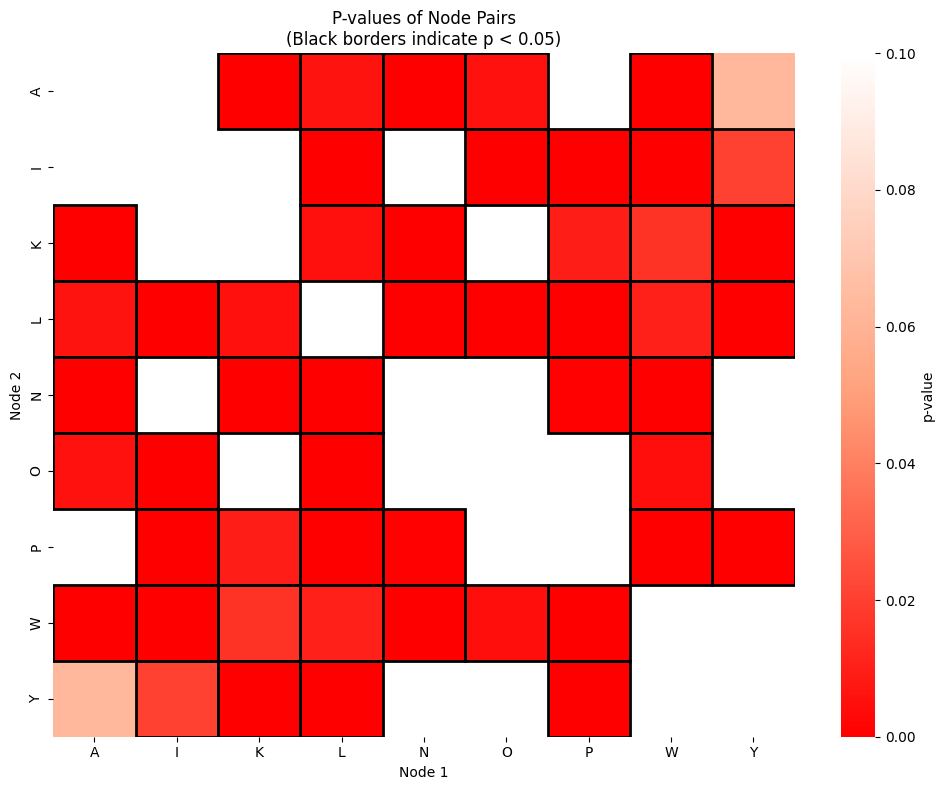

In [12]:
# Get all unique nodes that appear in either start or end positions
all_nodes = sorted(list(set([n for pair in pairs_with_diff + pairs_no_diff for n in pair])))

# Create matrices to store the significance values and mask
sig_matrix = np.zeros((len(all_nodes), len(all_nodes)))
mask = np.ones((len(all_nodes), len(all_nodes)))

# Fill the matrices
for start, end in pairs_with_diff + pairs_no_diff:
    start_idx = all_nodes.index(start)
    end_idx = all_nodes.index(end)
    sig_matrix[end_idx, start_idx] = pvalues[(start, end)]
    sig_matrix[start_idx, end_idx] = pvalues[(start, end)]
    mask[end_idx, start_idx] = 0
    mask[start_idx, end_idx] = 0

# Set diagonal to light grey by removing mask
for i in range(len(all_nodes)):
    mask[i,i] = 0
    sig_matrix[i,i] = np.nan  # Use NaN to exclude from colormap

# Create custom colormap with dark red for high p-values (less significant)
colors = ['#FF0000', '#FFA07A', '#FFFFFF']  # Red to light salmon to white
n_bins = 100
cmap = sns.blend_palette(colors, n_bins, as_cmap=True)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sig_matrix,
            xticklabels=all_nodes,
            yticklabels=all_nodes,
            cmap=cmap,
            mask=mask,
            vmin=0,
            vmax=0.1,  # Adjust this to control color intensity
            cbar_kws={'label': 'p-value'})

# Add black borders to significant squares (p < 0.05)
for i in range(len(all_nodes)):
    for j in range(len(all_nodes)):
        if not mask[i,j] and sig_matrix[i,j] < 0.05 and i != j:  # Skip diagonal
            plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2))

plt.xlabel('Node 1')
plt.ylabel('Node 2')
plt.title('P-values of Node Pairs\n(Black borders indicate p < 0.05)')
plt.tight_layout()
plt.show()

#### Are women different from men?

In [13]:
# merged_test_df[["Sex", "is_man", "Proportion Correct (new version)", "subj_mean_acc"]]

# QUARTILES DIFFERENT
men_flow_trees = []
women_flow_trees = []

min = 99

for (start_node, end_node), group in merged_test_df.groupby(["StartAt", "EndAt"]):
    group = group[group["accuracy"]]
    
    men_df = group[group["is_man"]]
    women_df = group[~group["is_man"]]

    min_num_trajs = np.min([women_df.shape[0], men_df.shape[0]])
    if min_num_trajs < 10: continue

    for i in range(5):
        sample_df1 = men_df.sample(n=10, random_state=i) 
        sample_df2 = women_df.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=node2)
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


        trajs2 = np.array(sample_df2["trajs"])
        G2 = generate_flow_tree_from_trajs(trajs2, END_NODE=node1)
        new_G2 = nx.relabel.convert_node_labels_to_integers(G2, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


        men_flow_trees.append(new_G1)
        women_flow_trees.append(new_G2)

print("Do Flow Trees from men and women have different diameters?")
men_diams = np.array([nx.diameter(FT) for FT in men_flow_trees])
women_diams = np.array([nx.diameter(FT) for FT in women_flow_trees])

run_ttest(men_diams, women_diams)
print()
run_permutation_test(men_diams, women_diams)
print()
run_homemade_permutation_test(men_diams, women_diams)


Do Flow Trees from men and women have different diameters?
Group 1 mean: 2.65 (var=1.08; n=200)
Group 2 mean: 3.37 (var=1.50; n=200)
T-statistic: -6.2803, P-value: 0.0000

Permutation test result: -0.715 (p=0.0002)
Mean within group 1 dist: 1.1 (var=0.85)
Mean within group 2 dist: 1.4 (var=1.2)
Mean between all group dist: 1.3 (var=1.1)
Within group 1 dist vs among all: -0.1797 (p=0.0001)
	T-statistic: -22.2399, P-value: 0.0000
Within group 2 dist vs among all: 0.04013 (p=1.0)
	T-statistic: 4.8279, P-value: 0.0000
Within group 1 dist vs within group 2: -0.2198 (p=0.0001)
	T-statistic: -21.8775, P-value: 0.0000

Permutation test: 0.7150 (p=0.0020)


(0.7150000000000003, 0.002)

In [14]:
print("Do Flow Trees from correct men and women have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(men_flow_trees + women_flow_trees)

men_embeddings = test_flow_tree_embedder.infer(men_flow_trees)
women_embeddings = test_flow_tree_embedder.infer(women_flow_trees)

men_embedding_means = np.array([100*np.mean(x) for x in men_embeddings])
women_embedding_means = np.array([100*np.mean(x) for x in women_embeddings])

run_ttest(men_embedding_means, women_embedding_means)
print()
run_permutation_test(men_embedding_means, women_embedding_means)
print()
run_homemade_permutation_test(men_embeddings, women_embeddings)


Do Flow Trees from correct men and women have different embeddings?
Group 1 mean: 0.00 (var=0.00; n=200)
Group 2 mean: 0.00 (var=0.00; n=200)
T-statistic: -0.0988, P-value: 0.9214

Permutation test result: -0.0003959 (p=0.929)
Mean within group 1 dist: 0.036 (var=0.0017)
Mean within group 2 dist: 0.043 (var=0.0016)
Mean between all group dist: 0.04 (var=0.0016)
Within group 1 dist vs among all: -0.00369 (p=0.0001)
	T-statistic: -11.5497, P-value: 0.0000
Within group 2 dist vs among all: 0.003512 (p=1.0)
	T-statistic: 11.0304, P-value: 0.0000
Within group 1 dist vs within group 2: -0.007203 (p=0.0001)
	T-statistic: -17.8379, P-value: 0.0000

Permutation test: 0.0075 (p=0.0020)


(0.0074568028, 0.002)

#### R/L/F dominant

In [15]:
overall_RL_labels = {('A', 'I'): 'F', ('A', 'K'): 'F', ('A', 'L'): 'F', ('A', 'N'): 'F', ('A', 'O'): 'R', ('A', 'P'): 'R', ('A', 'W'): 'L', ('A', 'Y'): 'F', ('I', 'A'): 'F', ('I', 'K'): 'R', ('I', 'L'): 'L', ('I', 'N'): 'R', ('I', 'O'): 'R', ('I', 'P'): 'L', ('I', 'W'): 'F', ('I', 'Y'): 'L', ('K', 'A'): 'F', ('K', 'I'): 'L', ('K', 'L'): 'L', ('K', 'N'): 'R', ('K', 'O'): 'R', ('K', 'P'): 'R', ('K', 'W'): 'L', ('K', 'Y'): 'F', ('L', 'A'): 'F', ('L', 'I'): 'R', ('L', 'K'): 'R', ('L', 'N'): 'R', ('L', 'O'): 'R', ('L', 'P'): 'R', ('L', 'W'): 'R', ('L', 'Y'): 'R', ('N', 'A'): 'F', ('N', 'I'): 'L', ('N', 'K'): 'L', ('N', 'L'): 'L', ('N', 'O'): 'L', ('N', 'P'): 'L', ('N', 'W'): 'L', ('N', 'Y'): 'L', ('O', 'A'): 'F', ('O', 'I'): 'L', ('O', 'K'): 'R', ('O', 'L'): 'L', ('O', 'N'): 'R', ('O', 'P'): 'R', ('O', 'W'): 'F', ('O', 'Y'): 'R', ('P', 'A'): 'L', ('P', 'I'): 'F', ('P', 'K'): 'F', ('P', 'L'): 'L', ('P', 'N'): 'R', ('P', 'O'): 'L', ('P', 'W'): 'F', ('P', 'Y'): 'L', ('W', 'A'): 'R', ('W', 'I'): 'L', ('W', 'K'): 'R', ('W', 'L'): 'L', ('W', 'N'): 'R', ('W', 'O'): 'F', ('W', 'P'): 'F', ('W', 'Y'): 'L', ('Y', 'A'): 'F', ('Y', 'I'): 'L', ('Y', 'K'): 'R', ('Y', 'L'): 'L', ('Y', 'N'): 'R', ('Y', 'O'): 'L', ('Y', 'P'): 'R', ('Y', 'W'): 'R'}

racc = []
rft = []
lacc = []
lft = []
facc = []
fft = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    acc = group["path_mean_acc"].iloc[0]

    winners_only = group[~group["accuracy"]]
    trajs = np.array(winners_only["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    
    if overall_RL_labels[(start_node, end_node)] == "R":
        racc.append(acc)
        rft.append(new_G)
    elif overall_RL_labels[(start_node, end_node)] == "L":
        lacc.append(acc)
        lft.append(new_G)
    else:
        facc.append(acc)
        fft.append(new_G)


print("Do righthand and lefthand paths have different accuracies?")
group1 = np.array(racc)
group2 = np.array(lacc)
group3 = np.array(facc)

run_ttest(group1, group2)
print()
run_permutation_test(group1, group2)
print()
run_homemade_permutation_test(group1, group2)
print("Right v even:")
run_ttest(group1, group3)
print("Left v even:")
run_ttest(group2, group3)
print()


print("Do righthand and lefthand Flow Trees have different diameters?")
group1 = np.array([nx.diameter(FT) for FT in rft])
group2 = np.array([nx.diameter(FT) for FT in lft])

run_ttest(group1, group2)
print()
run_permutation_test(group1, group2)
print()
run_homemade_permutation_test(group1, group2)

print()
print("Do righthand and lefthand Flow Trees have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(rft + lft + fft)

r_embeddings = test_flow_tree_embedder.infer(rft)
l_embeddings = test_flow_tree_embedder.infer(lft)

# run_ttest(r_embeddings, l_embeddings)
# print()
# run_permutation_test(r_embeddings, l_embeddings)
# print()
run_homemade_permutation_test(r_embeddings, l_embeddings)

Do righthand and lefthand paths have different accuracies?
Group 1 mean: 0.60 (var=0.01; n=27)
Group 2 mean: 0.55 (var=0.01; n=26)
T-statistic: 1.7783, P-value: 0.0813

Permutation test result: 0.04691 (p=0.0862)
Mean within group 1 dist: 0.13 (var=0.0081)
Mean within group 2 dist: 0.081 (var=0.0042)
Mean between all group dist: 0.11 (var=0.0068)
Within group 1 dist vs among all: 0.02134 (p=1.0)
	T-statistic: 4.2463, P-value: 0.0000
Within group 2 dist vs among all: -0.03004 (p=0.0001)
	T-statistic: -6.1356, P-value: 0.0000
Within group 1 dist vs within group 2: 0.05138 (p=1.0)
	T-statistic: 8.4368, P-value: 0.0000

Permutation test: 0.0469 (p=0.1340)
Right v even:
Group 1 mean: 0.60 (var=0.01; n=27)
Group 2 mean: 0.59 (var=0.01; n=19)
T-statistic: 0.3643, P-value: 0.7174
Left v even:
Group 1 mean: 0.55 (var=0.01; n=26)
Group 2 mean: 0.59 (var=0.01; n=19)
T-statistic: -1.4878, P-value: 0.1441

Do righthand and lefthand Flow Trees have different diameters?
Group 1 mean: 10.15 (var=1.83;

(0.014276003, 0.286)

Think of more gender questions:
- Is there difference in predictive power in women or men?


- Early v late in the test phase

Path questions:
- Can you tell from the flow tree if the path has a foil?


Hypothesis test -- permute trajectories of people doing flow tree vs doing it over just flow trees!

What is the range of path lengths people have when they get it wrong?

Are foils related to start or related to intended target?


right paths v left-leaning paths -- categoriacal variable and also continuous (proportion of rights and lefts among winners)